In [18]:
# 1. Import libraries
import pandas as pd
import time
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# import fasttext
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_selection import SelectKBest, chi2

In [22]:
# 2. Load and merge datasets
print('Loading training datasets...')
train_texts = pd.read_csv('training_datasets/train_text.csv')
train_labels = pd.read_csv('training_datasets/train_labels.csv')
train_df = pd.merge(train_texts, train_labels, on='id')

print('Loading testing datasets...')
test_texts = pd.read_csv('testing_datasets/test_text.csv')
test_labels = pd.read_csv('testing_datasets/test_labels.csv')
test_df = pd.merge(test_texts, test_labels, on='id')

print(f'Train size: {len(train_df)}, Test size: {len(test_df)}')

X_train = train_df['text']
X_test = test_df['text']
y_train = train_df['label']
y_test = test_df['label']

Loading training datasets...
Loading testing datasets...
Train size: 146068, Test size: 36517


In [23]:
print("Missing values in X_train:", X_train.isna().sum())
print("Missing values in X_test:", X_test.isna().sum())

Missing values in X_train: 0
Missing values in X_test: 0


In [ ]:
# 3. Define Feature Engineering Components\n
print('Defining FeatureUnion (word ngrams + char_wb ngrams) and Chi-Squared Selector...')
word_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True,
    strip_accents='unicode'
)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 4),
    min_df=3,
    sublinear_tf=True,
    strip_accents='unicode'
)

feature_union = FeatureUnion([
    ('word_tfidf', word_vectorizer),
    ('char_tfidf', char_vectorizer)
])

# Use Chi-Squared for feature selection (k sets how many top features to keep)
feature_selector = SelectKBest(score_func=chi2, k=25000)

Defining FeatureUnion (word ngrams + char_wb ngrams) and Chi-Squared Selector...


In [36]:
# 4. Train and Evaluate Multinomial Naive Bayes using Pipeline\n
print('Training Multinomial Naive Bayes Pipeline...')
mnb_pipeline = Pipeline([
    ('features', feature_union),
    ('selector', feature_selector),
    ('classifier', MultinomialNB())
])

start_time = time.time()
mnb_pipeline.fit(X_train, y_train)
mnb_train_time = time.time() - start_time

start_time = time.time()
mnb_preds = mnb_pipeline.predict(X_test)
mnb_test_time = time.time() - start_time

mnb_acc = accuracy_score(y_test, mnb_preds)
mnb_prec = precision_score(y_test, mnb_preds, average='macro')
mnb_rec = recall_score(y_test, mnb_preds, average='macro')
mnb_f1 = f1_score(y_test, mnb_preds, average='macro')

print(f'MNB Train Time: {mnb_train_time:.2f}s, Test Time: {mnb_test_time:.2f}s')
print(f'MNB Accuracy: {mnb_acc:.4f}')

Training Multinomial Naive Bayes Pipeline...
MNB Train Time: 29.18s, Test Time: 6.11s
MNB Accuracy: 0.7928


In [37]:
# 5. Train and Evaluate Logistic Regression using Pipeline\n
print('Training Logistic Regression Pipeline...')
lr_pipeline = Pipeline([
    ('features', feature_union),
    ('selector', feature_selector),
    ('classifier', LogisticRegression(max_iter=1000))
])

start_time = time.time()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.time() - start_time

start_time = time.time()
lr_preds = lr_pipeline.predict(X_test)
lr_test_time = time.time() - start_time

lr_acc = accuracy_score(y_test, lr_preds)
lr_prec = precision_score(y_test, lr_preds, average='macro')
lr_rec = recall_score(y_test, lr_preds, average='macro')
lr_f1 = f1_score(y_test, lr_preds, average='macro')

print(f'LR Train Time: {lr_train_time:.2f}s, Test Time: {lr_test_time:.2f}s')
print(f'LR Accuracy: {lr_acc:.4f}')

Training Logistic Regression Pipeline...
LR Train Time: 29.82s, Test Time: 5.59s
LR Accuracy: 0.9037


In [ ]:
# 6. FastText Implementation (Placeholder for now)
# import fasttext
#
# print('Training FastText...')
# start_time = time.time()
# ft_model = fasttext.train_supervised(input='training_datasets/train_fasttext.txt', epoch=25, lr=0.1, wordNgrams=2, verbose=2)
# ft_train_time = time.time() - start_time
#
# print('Testing FastText...')
# start_time = time.time()
# ft_results = ft_model.test('testing_datasets/test_fasttext.txt')
# ft_test_time = time.time() - start_time
#
# ft_samples, ft_prec, ft_rec = ft_results
# ft_f1 = 2 * (ft_prec * ft_rec) / (ft_prec + ft_rec) if (ft_prec + ft_rec) > 0 else 0
# print(f'FastText Precision: {ft_prec:.4f}')


In [38]:
# 7. Compare Models
results_data = {
    'Model': ['Multinomial Naive Bayes', 'Logistic Regression'], # Add 'FastText' later
    'Accuracy': [mnb_acc, lr_acc],
    'Precision (Macro)': [mnb_prec, lr_prec],
    'Recall (Macro)': [mnb_rec, lr_rec],
    'F1-Score (Macro)': [mnb_f1, lr_f1],
    'Train Time (s)': [mnb_train_time, lr_train_time],
    'Test Time (s)': [mnb_test_time, lr_test_time]
}

results_df = pd.DataFrame(results_data)
results_df

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),Train Time (s),Test Time (s)
0,Multinomial Naive Bayes,0.792781,0.768533,0.787337,0.775036,29.184135,6.107813
1,Logistic Regression,0.903743,0.904737,0.875386,0.887636,29.819861,5.585769


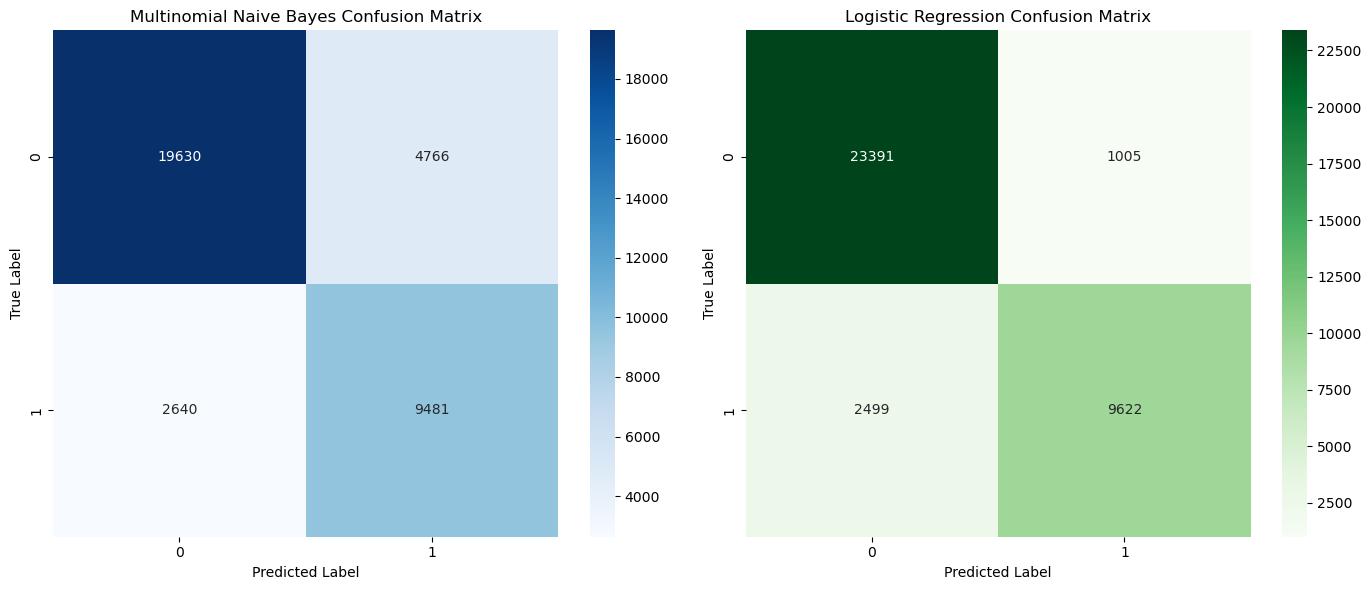

In [33]:
# 8. Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_mnb = confusion_matrix(y_test, mnb_preds)
sns.heatmap(cm_mnb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Multinomial Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

cm_lr = confusion_matrix(y_test, lr_preds)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

Loading test_leet.csv...
Predicting on Leetspeak Data with LR...
Leetspeak Test Time: 6.07s
Leetspeak LR Accuracy: 0.9850
Leetspeak LR F1 (Macro): 0.9829


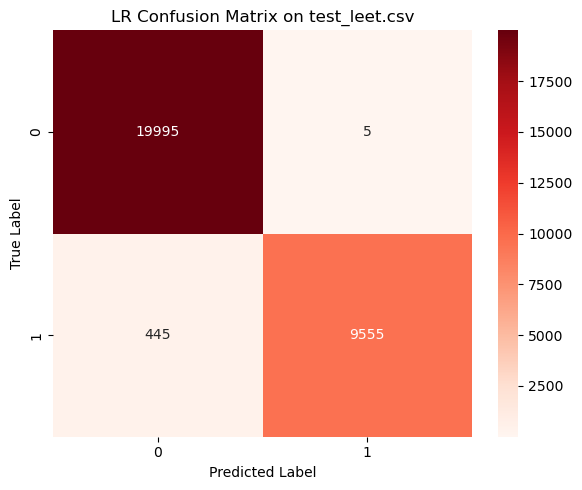

In [41]:
# 9. Evaluate LR Pipeline on Leetspeak Data
print('Loading test_leet.csv...')
leet_df = pd.read_csv('testing_datasets/test_leet.csv')
X_leet = leet_df['text'].astype(str).fillna('')
y_leet = leet_df['label']

print('Predicting on Leetspeak Data with LR...')
start_time = time.time()
leet_preds = lr_pipeline.predict(X_leet)
leet_test_time = time.time() - start_time

leet_acc = accuracy_score(y_leet, leet_preds)
leet_f1 = f1_score(y_leet, leet_preds, average='macro')

print(f'Leetspeak Test Time: {leet_test_time:.2f}s')
print(f'Leetspeak LR Accuracy: {leet_acc:.4f}')
print(f'Leetspeak LR F1 (Macro): {leet_f1:.4f}')

# Confusion Matrix for Leetspeak\n
fig, ax = plt.subplots(figsize=(6, 5))
cm_leet = confusion_matrix(y_leet, leet_preds)
sns.heatmap(cm_leet, annot=True, fmt='d', cmap='Reds', ax=ax)
ax.set_title('LR Confusion Matrix on test_leet.csv')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()